In [ ]:
import pandas as pd
import numpy as np

Examples inspired by https://medium.com/@basumatary18/implementing-linear-regression-on-california-housing-dataset-378e14e421b7

# scikit-learn intro

Before we get into the actual process of analyzing our data, let's introduce the module we will be using to aid us-- [scikit-learn](https://scikit-learn.org/stable/)

- provides data preprocessing and
"traditional" (non-deep learning) models
- Built on top of NumPy operations, with C underneath

# Things to know about scikit-learn

 scikit-learn uses a standard set of functions for all regression and classification models, called "Estimator" objects

 ## APIs

 - `model = Model()`: initialize a model with various optional parameters
 - `model.fit(X_train,y_train)`: train the model with the given data set
- `model.predict(X_test)`: get predictions for the given test set
- `model.score(X_test, y_test)`: how "good" were the predictions?

# Recall the full machine learning process:
1. data collection and cleaning
2. data preprocessing
3. model training
4. model evaluation
5. model deployment -> stay tuned for web dev section!


## Data collection and cleaning

In [ ]:
from sklearn.datasets import fetch_california_housing
cali_data = fetch_california_housing(as_frame=True)
print(cali_data['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
print(cali_data.data.shape, cali_data.target.shape)
print(cali_data.feature_names[0:6])

(20640, 8) (20640,)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']


In [ ]:
cali_df = cali_data.frame

In [ ]:
cali_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Luckily this data is cleaned for us already! This means we can move onto the next step...



# Data Preprocessing

we need to get our data into the "$X$" matrix form


$X$ may also be greater than 2-dimensional for complex data


Some ways to encode data:
1. numbers: encoding is easy, put directly into $X$
2. images: treat each pixel's RGB value as a number
3. sounds: decompose into amplitude and frequencies over time

In [ ]:
cali_df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
cali_df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64


# Check In - L11
What do these two queries tell us about our data, `cali_df`?

# Answer

Again, this dataset has already done this for us, time for step 3...

# EDA

Additionally, if necessary, you should do some EDA (visualizations are good) to see which attribute (column) you want to explore as the "answer"/predicted value.

In this case, we are told from the description that


> The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).


So we know that we want to isolate the column with the median house value in it as our $y$.

# Check In - C12

What is a target variable? What do we do with it? Why does it matter?

Explain why the median house value for CA districts is a good target variable.

# EDA contd.

If we had to pretend that we weren't given a target variable, one strategy we could use is plotting the correlations of the variables.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix


<Axes: >

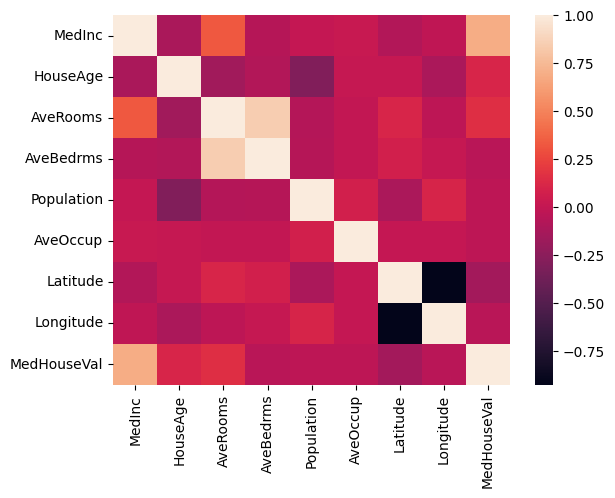

In [ ]:
cali_corr = cali_df.corr()
sns.heatmap(cali_corr)

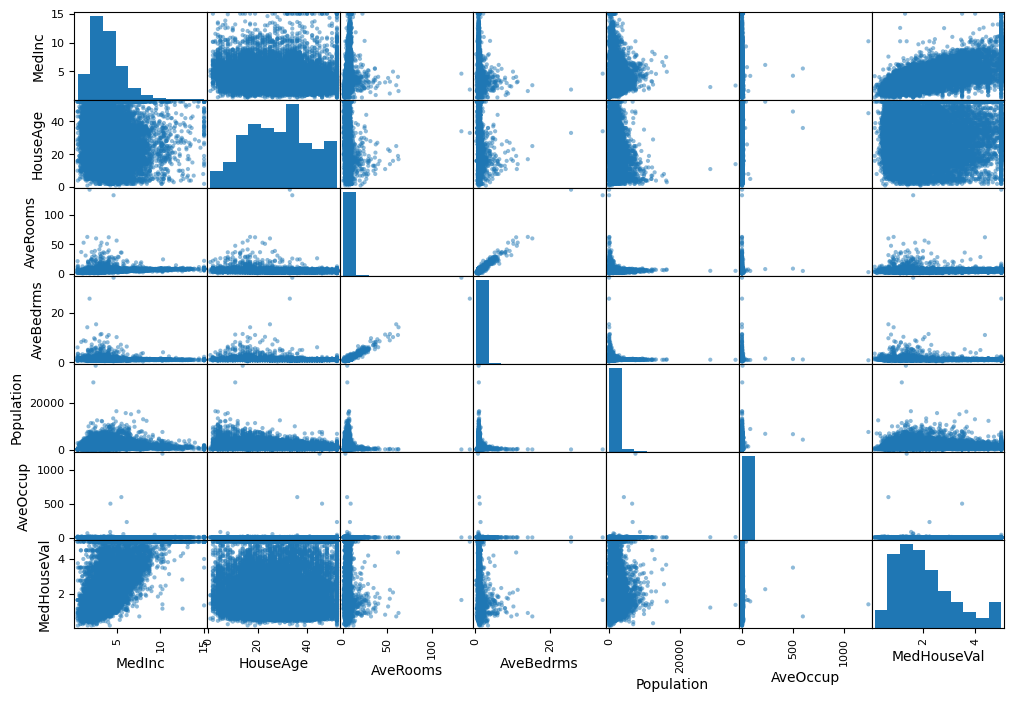

In [ ]:
attributes = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup','MedHouseVal']
scatter_matrix(cali_df[attributes], figsize=(12,8))
plt.show()

We can observe that agains MedHouseVal there is a somewhat weak correlation except for MedInc (median income)

In [ ]:
cali_corr['MedHouseVal'].sort_values(ascending=True)


,MedHouseVal
Latitude,-0.144160
AveBedrms,-0.046701
Longitude,-0.045967
Population,-0.024650
AveOccup,-0.023737
HouseAge,0.105623
AveRooms,0.151948
MedInc,0.688075
MedHouseVal,1.000000


This can be confirmed by zooming on the correlation between these two attributes where we see a strong linear correlation!

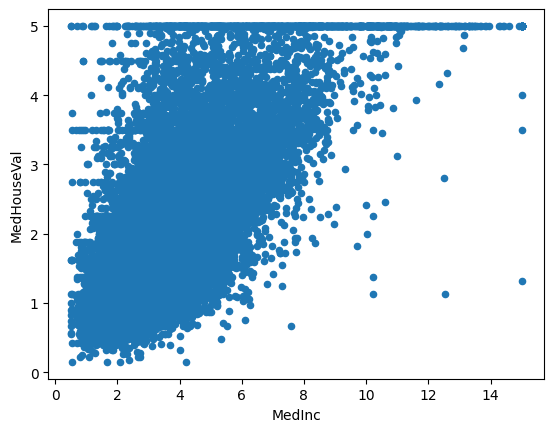

In [ ]:
cali_df.plot(kind="scatter", x="MedInc",y="MedHouseVal")
plt.show()

# Model Training

- partition the labeled data set into two sets. Remove the labels from one partition.
- this is called a **train/test split**
- train your model on the split with labels, while you evaluate the model on the other
split, comparing the predicted labels to the removed labels

Here, we are randomly splitting the data into training and testing set using `train_test_split()` method. 80% is kept for training and 20% for testing.

80-20 is a pretty common split ratio.

# Check In - L13

Why is 80-20 a good ratio for the split?

# Answer

Machine learning models generally improve with more training data. If you give too little data to training, the model may:

- learn weak patterns

- overfit noise

- fail to generalize

So we want the training set to be large.

Using 80% for training gives the model most of the available information.

If the test set is too small:

- the accuracy estimate becomes high variance

- results depend too much on which specific samples landed in the test set

| Split     | Training Quality  | Evaluation Reliability |
| --------- | ----------------- | ---------------------- |
| 90–10     | Great training    | Weak evaluation        |
| 50–50     | Weak training     | Strong evaluation      |
| **80–20** | **Good training** | **Good evaluation**    |


# Model Training Contd.

In [ ]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
X = cali_df.iloc[:,:-1]
y = cali_df.iloc[:,-1]

In [ ]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_... and y_... are given randomly assigned values from the original dataframe to be used to respectively train the model and then test how good the trained model is

In [ ]:
X_train

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
14196,3.2596,33.0,5.017657,1.006421,2300.0,3.691814,32.71,-117.03
8267,3.8125,49.0,4.473545,1.041005,1314.0,1.738095,33.77,-118.16
17445,4.1563,4.0,5.645833,0.985119,915.0,2.723214,34.66,-120.48
14265,1.9425,36.0,4.002817,1.033803,1418.0,3.994366,32.69,-117.11
2271,3.5542,43.0,6.268421,1.134211,874.0,2.300000,36.78,-119.80
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [ ]:
y_train

,MedHouseVal
14196,1.030
8267,3.821
17445,1.726
14265,0.934
2271,0.965
...,...
11284,2.292
11964,0.978
5390,2.221
860,2.835


# Fitting the model

## Choosing a model

Remember this is data where we want to predict some set of values based on some other given values, so we're using regression.

Additionally, we saw a linear correlation between two of the attributes we want to look into to see if one can predict the other. As such we're gonna use `Linear Regression`

## Linear regression
- we assume the form is linear (generalizing the familiar $y = ax + b$ form):

> $f(x) =w_1x_1 + w_2x_2 + ... +
w_dx_d$

- we find the optimal weights $w_i$ that minimize the error between $f(x)$ and $y$

### Linear Regression in sklearn

$ \hat(y) = w_1x_1 + w_2x_2 + ... +
w_dx_d$

- `model = LinearRegression()`
- `model.fit(X,y)`: find the optimal weights that minimize the "error" between $\hat(y)$
and $y$
- after model is fitted:
  - `model.predict(X)`: return predicted $\hat(y)$
  - `model.score(X, y)`: return the $R^2$ score of the predictions

1. Create the model
2. fit the model on the training data

In [ ]:
regressor = LinearRegression()
# make sure you use the right X and y!
regressor.fit(X_train, y_train)

LinearRegression()

3. use the model that was fit to predict the new target/"answer" values on the test set
4. this gives you a new array of values that would be predicted for their respective `X_test` tuple values

In [ ]:
y_pred = regressor.predict(X_test)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

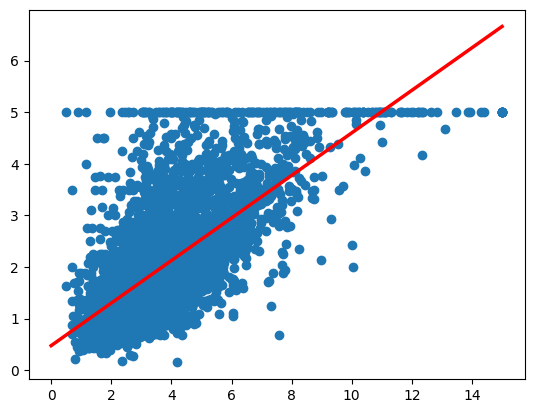

In [ ]:
plt.scatter(X_test['MedInc'], y_test)
b, a = np.polyfit(X_test['MedInc'], y_test, deg=1)

xseq = np.linspace(0, max(X_test['MedInc']), num=100)

# Plot regression line
plt.plot(xseq, a + b * xseq, color="red", lw=2.5)
plt.show()

In [ ]:
max(y_test)

5.00001

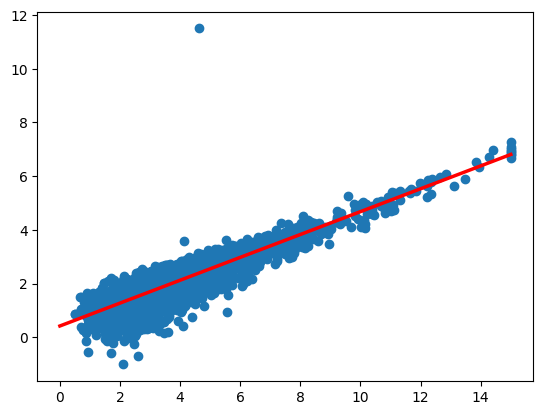

In [ ]:
plt.scatter(X_test['MedInc'], y_pred)
b, a = np.polyfit(X_test['MedInc'], y_pred, deg=1)

xseq = np.linspace(0, max(X_test['MedInc']), num=100)

# Plot regression line
plt.plot(xseq, a + b * xseq, color="red", lw=2.5)
plt.show()

# Check In - C14

What are the steps I listed needed to fit a model?
1. ...

2. ...

3. ...

4. ...

# Answer

1. Create the model
2. fit the model on the training data
3. use the model that was fit to predict the new target/"answer" values on the test set
4. this gives you a new array of values that would be predicted for their respective `X_test` tuple values

# Model Evaluation

- need a metric for evaluating how good a model is
  - again, no single "correct" choice for a metric
- for regression, $R^2$ can be used as a metric
  - "how much variance is explained by the prediction?"
- for classification, **accuracy** can be used as a metric
  - "what percentage of examples are labelled correctly?

In [ ]:
regressor.score(X_test, y_test)

0.5757877060324508

This isn't a great correlation score, but it's better than 0

# What makes linear regression machine learning?
- automatic feature selection
  - [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html), L0 regression
- weight penalties to control complexity
  - [Ridge Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) and [Elastic Net](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

# More on evaluation: the bias-variance tradeoff
1. Overfitting: can't generalize very well
    - too much variance
    - too "complex"
2. Underfitting: can't remember very well
    - too much bias
    - too "simple"

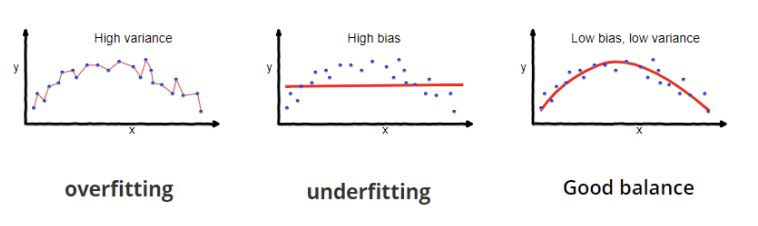

# Even more on model evaluation: Cross Validation

Instead of one train/test split, we split the data into 5 parts and rotate which part is used as the test set.

- This helps reduce dependence on on split and allows us to take a step back and get a better average of the results.

- Also helps reduce randomness.

- Overall, the goal is to get a more reliable estimate of how your model will perform on new, unseen data.

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
# Use only MedInc as the feature
X_single = X[['MedInc']]

model = LinearRegression()

# Create a 5-fold cross-validator: splits data into 5 parts and shuffles before splitting
# This example uses a fixed random seed so results are reproducible.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Create a list to track the scores of the 5 folds
scores = []

# kf.split(X_single) does NOT actually split the data itself
# instead, it generates indices that tell you how to split the data.
for train_index, test_index in kf.split(X_single):
    X_train = X_single.iloc[train_index]
    X_test  = X_single.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test  = y.iloc[test_index]

    # Fit model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    score = model.score(X_test, y_test)
    scores.append(score)

print("Scores for each fold:", scores)
print("Average score:", np.mean(scores))

Scores for each fold: [0.45885918903846656, 0.4816696744239797, 0.4699974253269812, 0.49117561775290997, 0.464304728698578]
Average score: 0.4732013270481831


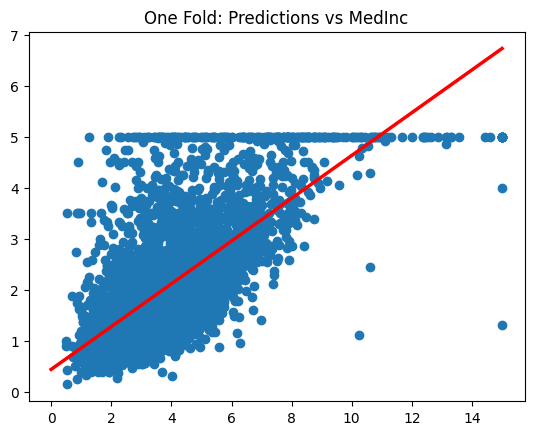

In [ ]:
plt.scatter(X_test['MedInc'], y_test)

b, a = np.polyfit(X_test['MedInc'], y_pred, deg=1)
xseq = np.linspace(0, max(X_test['MedInc']), num=100)

plt.plot(xseq, a + b * xseq, lw=2.5, color='red')
plt.title("One Fold: Predictions vs MedInc")
plt.show()

# Classification

From the slides:

- answers are discrete labels (can be more than 2), such as whether the house will appreciate or depreciate in value
- we code the class labels as integers
  - 0 = "depreciate"
  - 1 = "appreciate"
  - $y$ is a vector of shape containing 0s and 1s:$y \in \{0,1\}^n$

What if we made a classifier that was equivalent to a coin flip?

In [ ]:
import random

In [ ]:
# classifier should tell us whether a value is even or odd
# 0 is even, 1 is odd

X_train = [1, 4, 3, 6, 2, 7, 8]
y_train = [1, 0, 1, 0, 0, 1, 0]
X_test = [2, 4, 5, 3, 3, 4, 9]
expected_y_test = [0, 0, 1, 1, 1, 0, 1]

In [ ]:
y_test = []
for _ in range(len(X_test)):
  y_test.append(random.randint(0,1))

print(y_test)

[1, 0, 0, 1, 0, 1, 1]


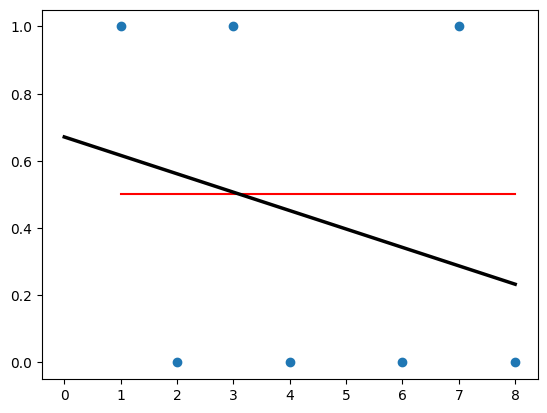

In [ ]:
plt.scatter(X_train, y_train)
plt.plot([1, 8], [0.5, 0.5], 'r')
b, a = np.polyfit(X_train, y_train, deg=1)

xseq = np.linspace(0, max(X_train), num=100)

# Plot regression line
plt.plot(xseq, a + b * xseq, color="k", lw=2.5)
# plt.plot(X_test, y_test)
plt.show()

Everytime we run it, there's a 50% chance it gets any individual value in `y_test` correct.

This example isn't actually trained on existing data.

# Check in - S7

Is this an example of underfitting or overfitting?

# What if

What about if we made a classifier that always predicts the most frequent class?

In [ ]:
count_0 = 0
count_1 = 0
for elem in X_train:
  if elem % 2 == 0:
    count_0 += 1
  else:
    count_1 += 1

print(count_0)
print(count_1)

classifier = 0 if count_0 > count_1 else 1

4
3


In [ ]:
y_pred = [classifier] * len(X_test)
print(y_pred)

[0, 0, 0, 0, 0, 0, 0]


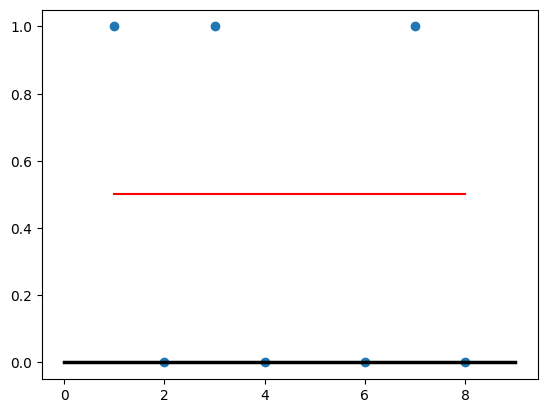

In [ ]:
plt.scatter(X_train, y_train)
plt.plot([1, 8], [0.5, 0.5], 'r')
# plt.plot(X_test, y_pred)
b, a = np.polyfit(X_test, y_pred, deg=1)

xseq = np.linspace(0, max(X_test), num=100)

# Plot regression line
plt.plot(xseq, a + b * xseq, color="k", lw=2.5)
plt.show()

# Check in - S8

Is this an example of underfitting or overfitting?

# Classification using sklearn


https://www.datacamp.com/community/tutorials/machine-learning-in-r

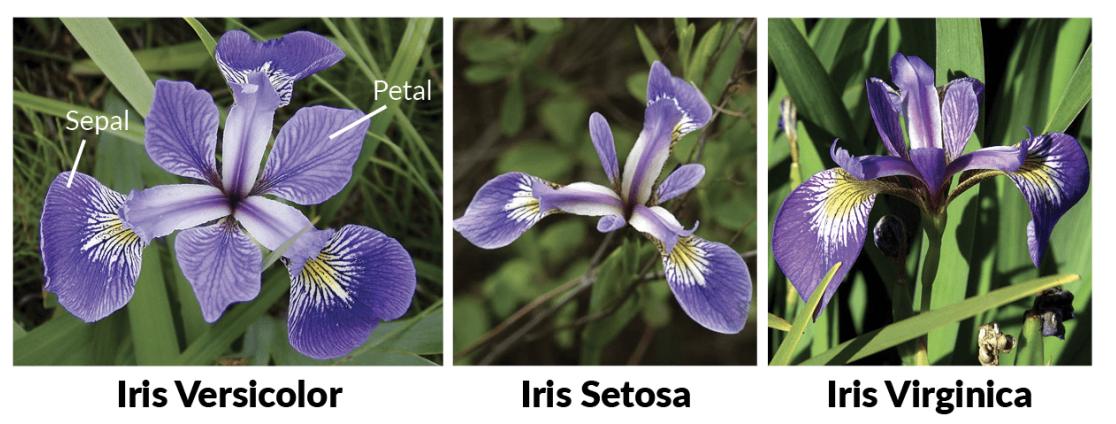

plotting code from: https://scikit-learn.org/stable/auto_examples/neighbors/plot_nca_classification.html

adapted by Tony Liu

In [ ]:
from sklearn.datasets import load_iris
from matplotlib.colors import ListedColormap

# Create color maps red green blue
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

iris_data = load_iris()
iris_data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
print(iris_data['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

Text(0, 0.5, 'sepal width')

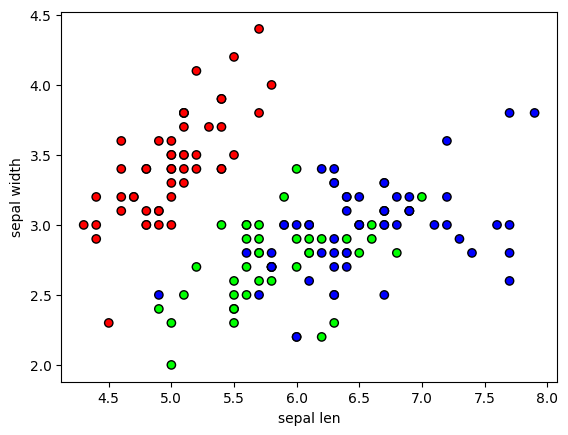

In [ ]:
from sklearn.datasets import load_iris
from matplotlib.colors import ListedColormap

# Create color maps            red        green       blue
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

dataset = load_iris()

X = dataset['data']
X = X[:, :2]

y = dataset['target']

fig, ax = plt.subplots()

ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor="black")
ax.set_xlabel("sepal len")
ax.set_ylabel("sepal width")


Let's add a little bit of magic so we can visualize our classifiers.

In [ ]:
def plot_decision_boundary(X, y, clf, clf_name, ax):
    """
    Plots the decision boundary of the classifier fit to the given data on the specified Axes.

    Adapted from: https://scikit-learn.org/stable/auto_examples/neighbors/plot_nca_classification.html

    Args:
        X ((n, 2) np.ndarray): The two-feature input matrix
        y ((n,) np.ndarray): The length n input ys
        clf (sklearn Classifier): the classifier to fit
        clf_name (str): the name of the classifier
        ax (matplotlib.axes.Axes): the Axes to plot the decision boundary.

    Returns:
        None, but plots to ax
    """
    h = .03  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    X_train, X_test, y_train, y_test = \
    train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)

    # Plot the decision boundary. For that, we will assign a color to each
    # point in the mesh [x_min, x_max] by [y_min, y_max].
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)

    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

    ax.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=.8, shading="auto")
    ax.set_title("{} accuracy: {:.2f}".format(clf_name, score))

# Types of Classifiers

## DummyClassifier

1. Pick a baseline classification
2. Return that for all inputs
(ignore inputs)

In [ ]:
from sklearn.dummy import DummyClassifier

DummyClassifier?

Text(0, 0.5, 'sepal width')

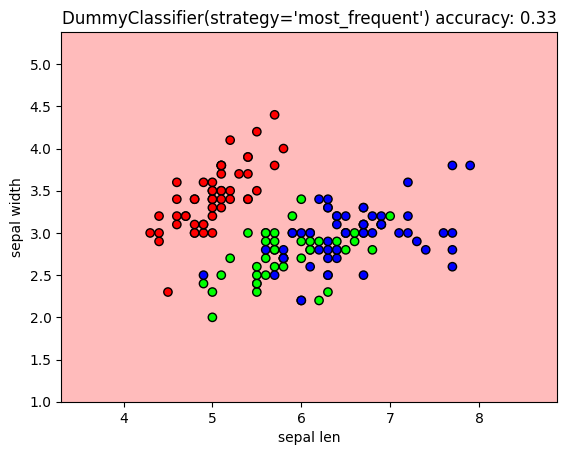

In [ ]:
dataset = load_iris()

X, y = dataset['data'], dataset['target']
X = X[:, :2]

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Create color maps            red        green       blue
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])


clf = DummyClassifier(strategy="most_frequent")
fig, ax = plt.subplots()

plot_decision_boundary(X, y, clf, str(clf), ax)



ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor="black")
ax.set_xlabel("sepal len")
ax.set_ylabel("sepal width")

That looks... bad, I think we can do better.

Another classifier is the decision tree.

## Decision Tree

1. Start at the root: Check the value of a selected feature (a question about the data).
2. Follow the branch: Based on the answer, move to the corresponding child node.
3. Repeat decisions: Continue evaluating features at each node and following branches.
4. Reach a leaf node: Stop when no further splits occur.
5. Output prediction: The leaf node provides the final class label or numeric prediction.

Hyperparameters (which can be "tuned"):

- `max_depth` – Maximum depth of the tree (limits how many splits from root to leaf).

- `min_samples_split` – Minimum number of samples required in a node before it can be split.

- `min_samples_leaf` – Minimum number of samples required in a leaf node.

- `max_features` – Number of features the model considers when choosing the best split.

- `criterion` – The metric used to evaluate split quality (e.g., gini or entropy for classification, squared error for regression).

- `max_leaf_nodes` – Maximum number of leaf nodes allowed in the tree.

- `min_impurity_decrease` – Minimum improvement in impurity needed to make a split.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DecisionTreeClassifier?

Text(0, 0.5, 'sepal width')

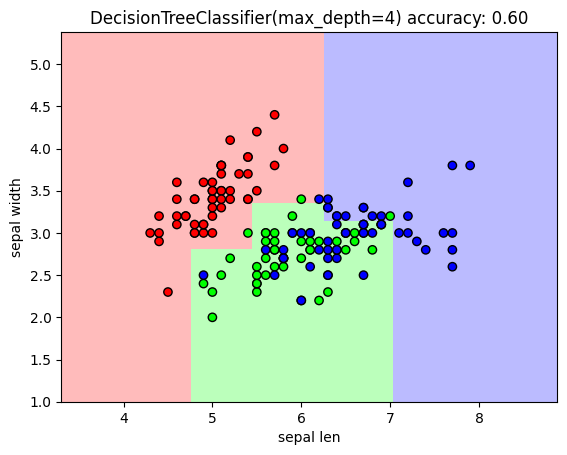

In [ ]:
dataset = load_iris()

X, y = dataset['data'], dataset['target']
X = X[:, :2]

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Create color maps            red        green       blue
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

clf = DecisionTreeClassifier(max_depth=4)
fig, ax = plt.subplots()

plot_decision_boundary(X, y, clf, str(clf), ax)



ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor="black")
ax.set_xlabel("sepal len")
ax.set_ylabel("sepal width")

This... is better, for sure. But let's just try one more strategy to be safe.

(side note: random forests)

# Unsupervised Learning and Clustering
## K-Nearest Neighbor (KNN)

1. place labelled examples in vector space
2. place new instance in vector space
3. find the closest instances to the new one
4. the prediction for the new instance is the majority class of the $k$ nearest neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
KNeighborsClassifier?

Text(0, 0.5, 'sepal width')

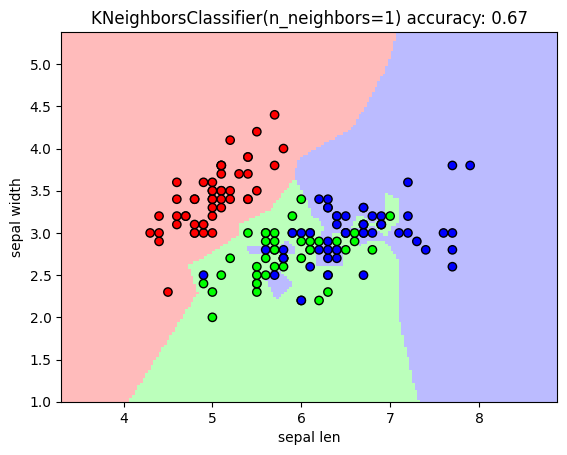

In [ ]:
dataset = load_iris()

X, y = dataset['data'], dataset['target']
X = X[:, :2]

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# Create color maps            red        green       blue
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

clf = KNeighborsClassifier(n_neighbors=1)
fig, ax = plt.subplots()

plot_decision_boundary(X, y, clf, str(clf), ax)



ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor="black")
ax.set_xlabel("sepal len")
ax.set_ylabel("sepal width")

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


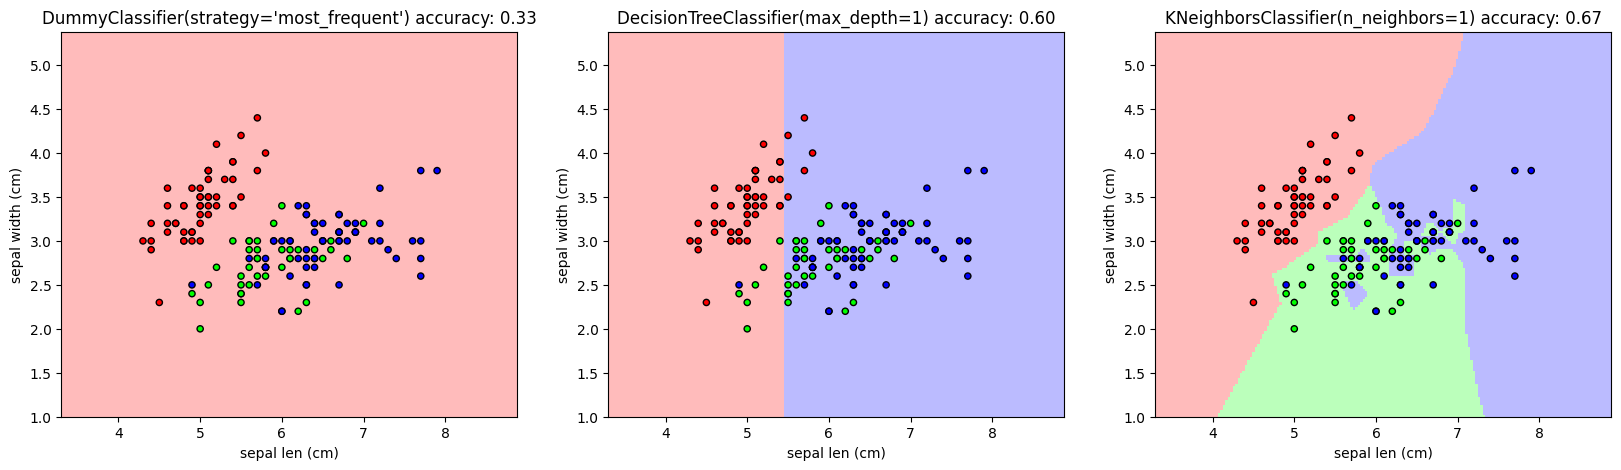

In [ ]:
from sklearn.datasets import load_iris

dataset = load_iris()
X, y = dataset.data, dataset.target
print(dataset['feature_names'])
print(dataset['target_names'])

# correspond to sepal length, sepal width
X = X[:, :2]

# this is underfit!
dummy = DummyClassifier(strategy="most_frequent")

# this is still slightly underfit
tree = DecisionTreeClassifier(max_depth=1)

# may be overfit
knn = KNeighborsClassifier(n_neighbors=1)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
plot_decision_boundary(X, y, dummy, str(dummy), ax[0])
plot_decision_boundary(X, y, tree, str(tree), ax[1])
plot_decision_boundary(X, y, knn, str(knn), ax[2])

for i in range(3):
  ax[i].scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor="black", s=20)
  ax[i].set_xlabel("sepal len (cm)")
  ax[i].set_ylabel("sepal width (cm)")
plt.show()